In [ ]:
                                                                Milestone-4 
                                                            Incident Type Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for better visuals
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [2]:
file_path = r"C:\Users\Admin\Downloads\database.csv.zip"
df = pd.read_csv(file_path, compression='zip')

df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [3]:
df.columns

Index(['Declaration Number', 'Declaration Type', 'Declaration Date', 'State',
       'County', 'Disaster Type', 'Disaster Title', 'Start Date', 'End Date',
       'Close Date', 'Individual Assistance Program',
       'Individuals & Households Program', 'Public Assistance Program',
       'Hazard Mitigation Program'],
      dtype='object')

In [5]:
# rename columns to match milestone requirements
df = df.rename(columns={
    'Disaster Type': 'incidentType',
    'State': 'state',
    'Declaration Date': 'declarationDate',
    'Individual Assistance Program': 'ihProgramDeclared',
    'Public Assistance Program': 'paProgramDeclared'
})

# convert date to datetime
df['declarationDate'] = pd.to_datetime(df['declarationDate'], errors='coerce')

# extract year and month
df['year'] = df['declarationDate'].dt.year
df['month'] = df['declarationDate'].dt.month

# check result
df[['incidentType','state','year','month','ihProgramDeclared','paProgramDeclared']].head()

,incidentType,state,year,month,ihProgramDeclared,paProgramDeclared
0,Tornado,GA,1953,5,Yes,Yes
1,Tornado,TX,1953,5,Yes,Yes
2,Flood,LA,1953,5,Yes,Yes
3,Tornado,MI,1953,6,Yes,Yes
4,Flood,MT,1953,6,Yes,Yes


In [6]:
# remove missing values in important columns
df = df.dropna(subset=['incidentType', 'state'])

# convert to proper types
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['month'] = pd.to_numeric(df['month'], errors='coerce')

In [7]:
incident_counts = df['incidentType'].value_counts().reset_index()
incident_counts.columns = ['incidentType', 'count']

incident_counts.head()

,incidentType,count
0,Storm,16250
1,Flood,9317
2,Hurricane,8764
3,Snow,3565
4,Fire,2647


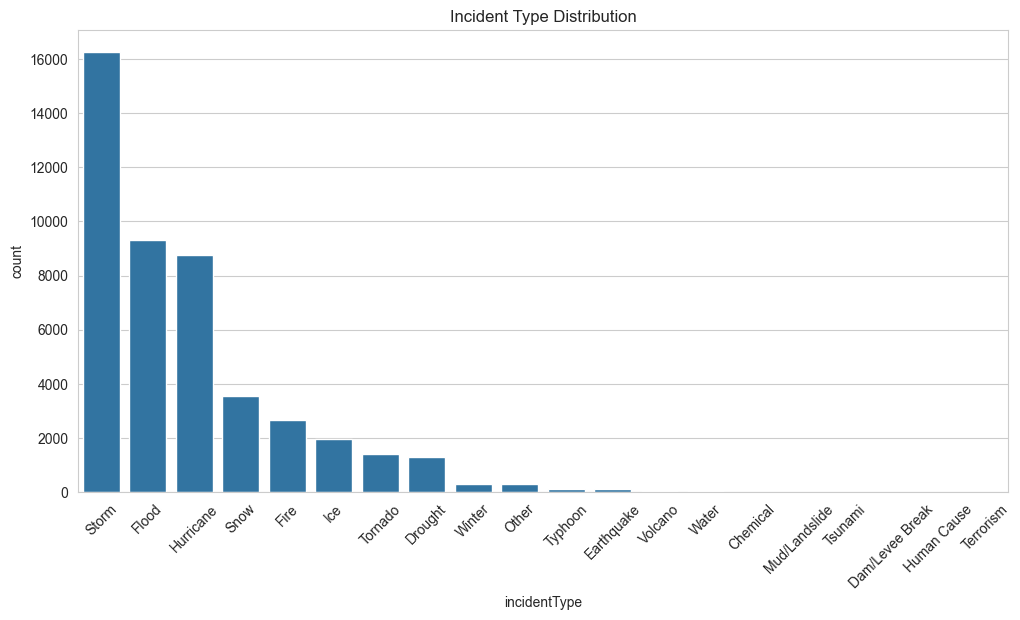

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(data=incident_counts, x='incidentType', y='count')
plt.xticks(rotation=45)
plt.title("Incident Type Distribution")
plt.show()

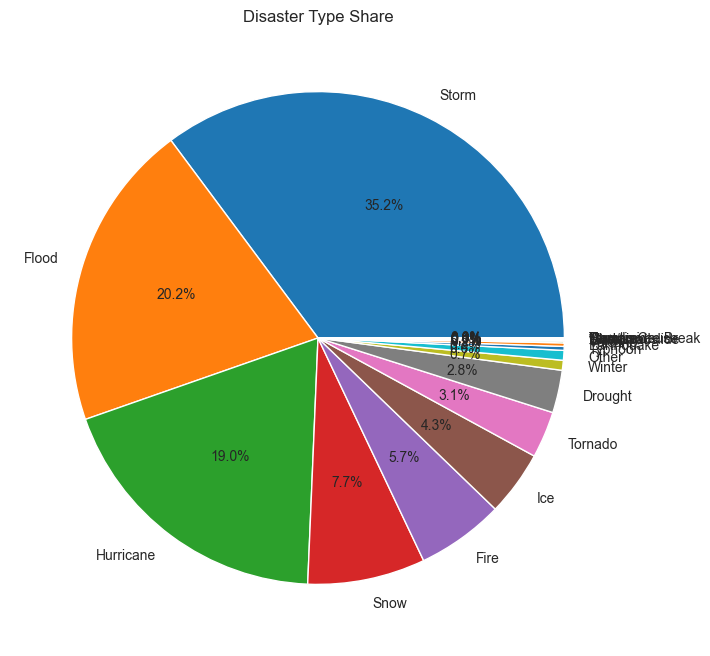

In [9]:
plt.figure(figsize=(8,8))
plt.pie(incident_counts['count'], labels=incident_counts['incidentType'], autopct='%1.1f%%')
plt.title("Disaster Type Share")
plt.show()

In [10]:
state_incident = df.groupby(['state', 'incidentType']).size().reset_index(name='count')

state_incident.head()

,state,incidentType,count
0,AK,Earthquake,7
1,AK,Fire,16
2,AK,Flood,46
3,AK,Other,4
4,AK,Snow,4


In [12]:
heatmap_data = state_incident.pivot(index='state', columns='incidentType', values='count').fillna(0)

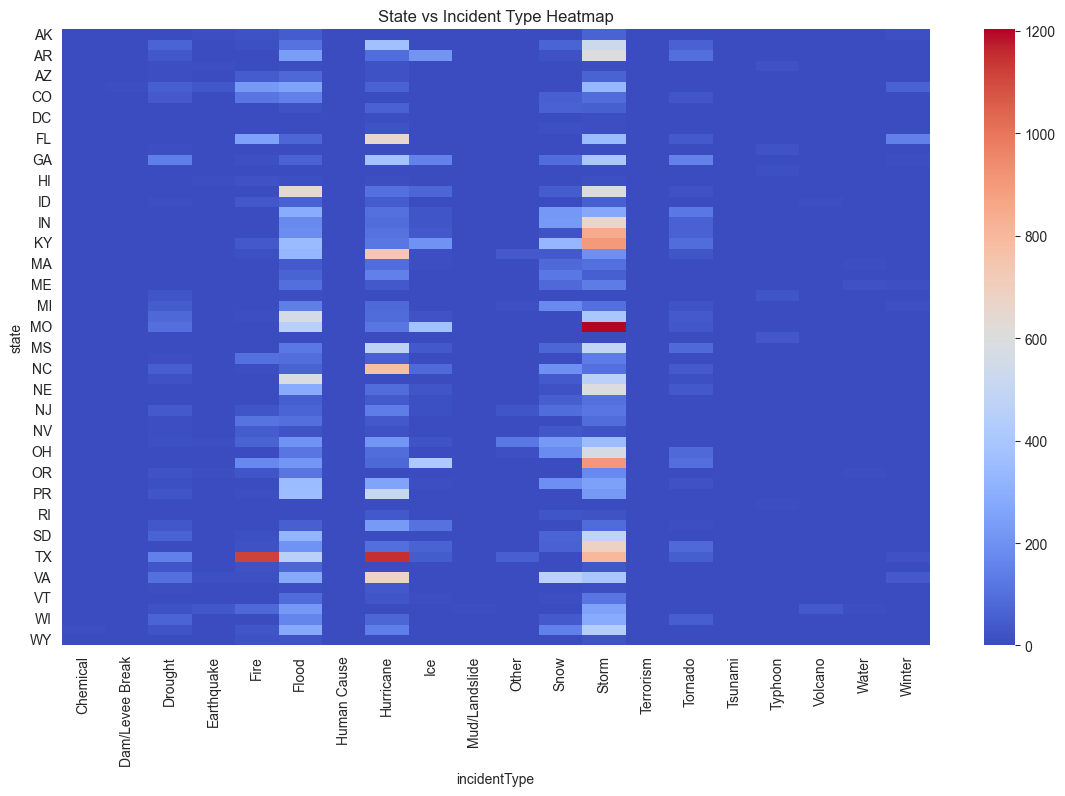

In [13]:
plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap='coolwarm')
plt.title("State vs Incident Type Heatmap")
plt.show()

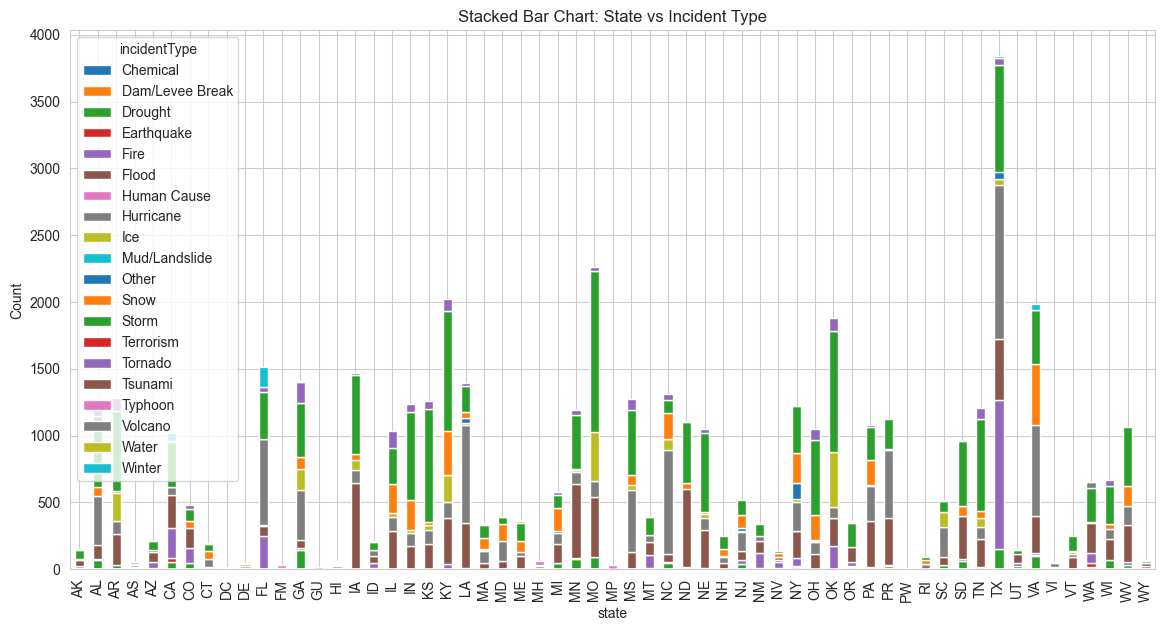

In [14]:
stacked_data = heatmap_data

stacked_data.plot(kind='bar', stacked=True, figsize=(14,7))
plt.title("Stacked Bar Chart: State vs Incident Type")
plt.ylabel("Count")
plt.show()

In [15]:
assistance_analysis = df.groupby('incidentType')[['ihProgramDeclared', 'paProgramDeclared']].sum().reset_index()

assistance_analysis.head()

,incidentType,ihProgramDeclared,paProgramDeclared
0,Chemical,YesYesNoNoNoYesNoNoNoNoNoNoNoNoNoNoNoNo,YesYesYesYesYesNoYesYesYesYesYesYesYesYesYesYe...
1,Dam/Levee Break,YesNoNoNoNoNo,YesYesYesYesYesYes
2,Drought,YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesY...,YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesY...
3,Earthquake,YesYesYesYesYesYesYesYesYesYesNoYesYesYesYesYe...,YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesY...
4,Fire,YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesY...,YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesY...


In [19]:
plt.figure(figsize=(12,6))

x = np.arange(len(assistance_analysis['incidentType']))

plt.bar(x - 0.2, assistance_analysis['ihProgramDeclared'], width=0.4, label='IH Program')
plt.bar(x + 0.2, assistance_analysis['paProgramDeclared'], width=0.4, label='PA Program')

plt.xticks(x, assistance_analysis['incidentType'], rotation=45)
plt.title("Incident Type vs Assistance Programs")
plt.xlabel("Incident Type")
plt.ylabel("Count")
plt.legend()

plt.show()

1. Flood and Storm are most frequent disasters
2. Some states repeatedly face specific disasters
3. Disaster frequency is higher in certain regions
4. Public Assistance is more common than Individual Housing